In [ ]:
!pip install simpy

Core mechanics of Simpy



In [ ]:
import simpy

def clock(env, tick_interval):
    """A simple process that prints the time every tick_interval seconds."""
    while True:
        print(f"Tick! The simulation time is currently: {env.now}")

        # Pause this process for 'tick_interval' virtual seconds
        yield env.timeout(tick_interval)

# 1. Create the simulation environment (the virtual clock)
env = simpy.Environment()

# 2. Add our clock process to the environment
env.process(clock(env, tick_interval=2))

# 3. Run the simulation for 10 virtual seconds
print("Starting the clock...")
env.run(until=10)
print("Simulation finished.")

Starting the clock...
Tick! The simulation time is currently: 0
Tick! The simulation time is currently: 2
Tick! The simulation time is currently: 4
Tick! The simulation time is currently: 6
Tick! The simulation time is currently: 8
Simulation finished.


Case Study: Single-Server ATM Machine

In [ ]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulation Parameters ---
RANDOM_SEED = 42
INTERARRIVAL_TIME = 3.0  # Average time between arrivals
SERVICE_TIME = 4.0       # Average time to use the ATM
SIM_TIME = 500           # Total minutes to simulate

# We will use this list to collect data for analysis later!
wait_times = []

# --- 2. Defining the Processes ---

def customer(env, name, atm):
    """Models a single customer using the ATM."""
    arrival_time = env.now
    print(f"[{arrival_time:06.2f}] {name} arrived at the ATM.")

    # Request the ATM (This automatically adds the customer to the queue if it's busy)
    with atm.request() as request:
        # Pause the customer until it's their turn
        yield request

        # Calculate how long they waited
        wait_time = env.now - arrival_time
        wait_times.append(wait_time)
        print(f"[{env.now:06.2f}] {name} started using the ATM (Waited: {wait_time:.2f} mins).")

        # Simulate the time it takes to do the bank transaction
        # We use an exponential distribution for randomness
        time_at_atm = np.random.exponential(SERVICE_TIME)
        yield env.timeout(time_at_atm)

        print(f"[{env.now:06.2f}] {name} finished and left.")

def customer_generator(env, atm):
    """Generates new customers infinitely over time."""
    customer_id = 1
    while True:
        # Determine the time until the NEXT customer arrives
        time_until_next = np.random.exponential(INTERARRIVAL_TIME)

        # Pause the generator until that time passes
        yield env.timeout(time_until_next)

        # Create a new customer process
        env.process(customer(env, f"Customer {customer_id}", atm))
        customer_id += 1

# --- 3. Running the Simulation ---
print("--- Single-Server ATM Simulation ---")

# Set the random seed so our results are reproducible
np.random.seed(RANDOM_SEED)

# Create the environment and the single-server resource
env = simpy.Environment()
atm = simpy.Resource(env, capacity=1)

# Start the generator
env.process(customer_generator(env, atm))

# Run the virtual clock!
env.run(until=SIM_TIME)

print("\n--- Simulation Complete ---")


--- Single-Server ATM Simulation ---
[001.41] Customer 1 arrived at the ATM.
[001.41] Customer 1 started using the ATM (Waited: 0.00 mins).
[006.67] Customer 1 finished and left.
[010.44] Customer 2 arrived at the ATM.
[010.44] Customer 2 started using the ATM (Waited: 0.00 mins).
[011.12] Customer 2 finished and left.
[013.18] Customer 3 arrived at the ATM.
[013.18] Customer 3 started using the ATM (Waited: 0.00 mins).
[013.42] Customer 3 finished and left.
[013.69] Customer 4 arrived at the ATM.
[013.69] Customer 4 started using the ATM (Waited: 0.00 mins).
[017.36] Customer 4 finished and left.
[019.72] Customer 5 arrived at the ATM.
[019.72] Customer 5 started using the ATM (Waited: 0.00 mins).
[019.80] Customer 5 finished and left.
[023.41] Customer 6 arrived at the ATM.
[023.41] Customer 6 started using the ATM (Waited: 0.00 mins).
[030.56] Customer 6 finished and left.
[033.92] Customer 7 arrived at the ATM.
[033.92] Customer 7 started using the ATM (Waited: 0.00 mins).
[034.64]

Total customers served: 122
Average wait time: 81.49 minutes
Maximum wait time: 174.47 minutes


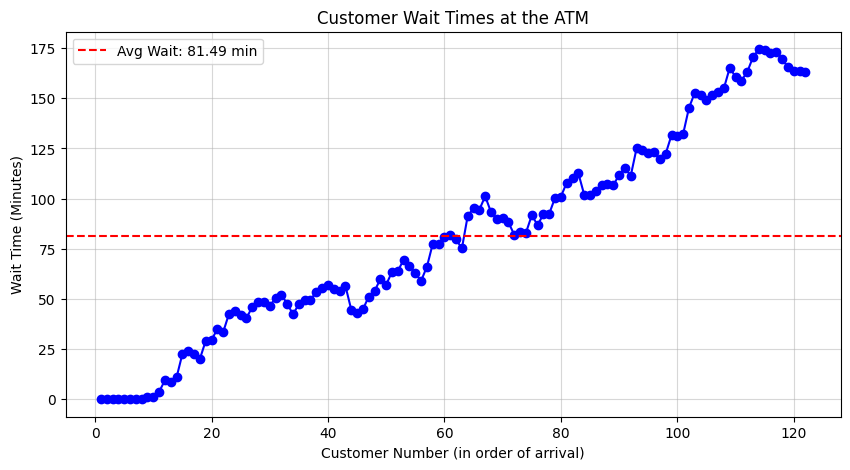

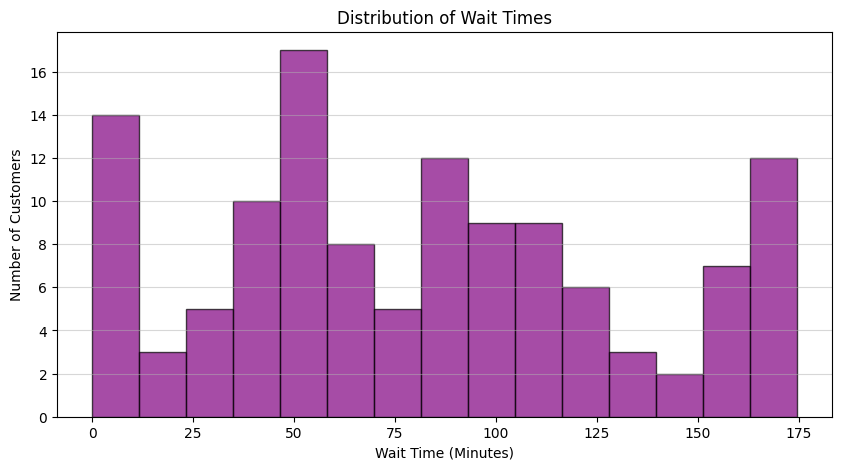

In [ ]:
# 1. Calculate basic statistics
average_wait = np.mean(wait_times)
max_wait = np.max(wait_times)
total_customers = len(wait_times)

print(f"Total customers served: {total_customers}")
print(f"Average wait time: {average_wait:.2f} minutes")
print(f"Maximum wait time: {max_wait:.2f} minutes")

# 2. Visualize the Wait Times
plt.figure(figsize=(10, 5))
plt.plot(range(1, total_customers + 1), wait_times, marker='o', linestyle='-', color='b')

plt.title("Customer Wait Times at the ATM")
plt.xlabel("Customer Number (in order of arrival)")
plt.ylabel("Wait Time (Minutes)")
plt.axhline(y=average_wait, color='r', linestyle='--', label=f'Avg Wait: {average_wait:.2f} min')
plt.legend()
plt.grid(True, alpha=0.5)

plt.show()

# 3. View the distribution of wait times
plt.figure(figsize=(10, 5))
plt.hist(wait_times, bins=15, color='purple', edgecolor='black', alpha=0.7)
plt.title("Distribution of Wait Times")
plt.xlabel("Wait Time (Minutes)")
plt.ylabel("Number of Customers")
plt.grid(axis='y', alpha=0.5)
plt.show()